In [13]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import matplotlib.pyplot as plt


# All analysis modules live inside the `logic/` package. Adding the
# package directory to sys.path keeps the flat `import config` /
# `from decoding import ...` style working inside the notebook without
# having to rewrite every intra-module import elsewhere.
LOGIC_DIR = (Path.cwd() / "logic").resolve()
if str(LOGIC_DIR) not in sys.path:
    sys.path.insert(0, str(LOGIC_DIR))

import numpy as np
import pandas as pd
from IPython.display import Image, display

import config
from config import FIG_DIR, TAB_DIR, RESULTS_DIR, RANDOM_STATE
from data_utils import build_dataset
from subsets import define_fixed_subsets
import pipeline

config.ensure_dirs()
ds = build_dataset()
subs = define_fixed_subsets(ds["electrode_group"])
print("meta:", ds["meta"])

meta: {'n_electrodes': 33, 'n_stimuli': 49, 'n_time': 201, 'dt_s': 0.010000000000000009, 'time_window_s': (0.0, 2.0), 'n_per_group': {'song': 7, 'speech': 15, 'music': 11}, 'n_per_class': {'song': 11, 'speech': 17, 'music': 21}, 'keep_classes': ['song', 'speech', 'music']}


In [22]:
import wave
import numpy as np
from bellier_data import load_vocal_segments
from config import BELLIER_AUDIO_PATH, BELLIER_FS, BELLIER_T, BELLIER_VOCAL_CSV

with wave.open(str(BELLIER_AUDIO_PATH), 'rb') as w:
    wav_dur = w.getnframes() / w.getframerate()
neural_dur = BELLIER_T / BELLIER_FS
print(f'WAV duration    : {wav_dur:.3f} s ({BELLIER_AUDIO_PATH.name})')
print(f'Neural duration : {neural_dur:.3f} s (T={BELLIER_T} @ {BELLIER_FS} Hz)')
print(f'Aligned         : {np.isclose(wav_dur, neural_dur, atol=0.01)} '
      f'-> no time-stretching, annotations are in real song time')

mask = load_vocal_segments()
diff = np.diff(mask.astype(int))
starts = np.where(diff == 1)[0] + 1
ends = np.where(diff == -1)[0] + 1
if mask[0]:  starts = np.r_[0, starts]
if mask[-1]: ends = np.r_[ends, len(mask)]
print(f'\nVocal CSV        : {BELLIER_VOCAL_CSV.name}')
print(f'Vocal samples    : {int(mask.sum())} / {len(mask)}  '
      f'({mask.mean()*100:.2f}%)')
print(f'Merged intervals : {len(starts)}')
for s, e in zip(starts, ends):
    print(f'  {s/BELLIER_FS:7.3f} - {e/BELLIER_FS:7.3f}  '
          f'({(e-s)/BELLIER_FS:.3f}s)')

WAV duration    : 190.720 s (thewall1.wav)
Neural duration : 190.720 s (T=19072 @ 100 Hz)
Aligned         : True -> no time-stretching, annotations are in real song time

Vocal CSV        : vocal_segments.csv
Vocal samples    : 5803 / 19072  (30.43%)
Merged intervals : 4
   15.080 -  16.900  (1.820s)
   17.460 -  19.150  (1.690s)
   24.410 -  29.570  (5.160s)
   42.660 -  92.020  (49.360s)


In [23]:
import importlib
import logic.pipeline as pipeline
importlib.reload(pipeline)

from logic.bellier_data import build_supergrid, load_vocal_segments

supergrid = build_supergrid()
vocal_present = load_vocal_segments()
all_electrodes = np.arange(supergrid["hfa"].shape[1])
# COME BACK THERE's ISSUES HERE

In [15]:
bellier_out = pipeline.run_bellier_vocal_component_model(
    supergrid=supergrid,
    vocal_present=vocal_present,
    K=5,
    activation_penalty=0.01,
    window_size=50,
    step_size=100,   # fewer windows
    n_perm=200,      # faster for debugging
    seed=0,
    n_iter=500,
    n_iter_per_eval=50,
)
bellier_out['component_stats']['best_component']
bellier_out['component_stats']['diff']
bellier_out['component_stats']['p']
bellier_out['top_electrodes']

2026-04-25 16:55:07.598134: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-25 16:55:07.598662: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


0 [0.03930356]
10 [0.03930356]
20 [0.03930356]
30 [0.03930356]
40 [0.03930356]
50 [0.03773995]
60 [0.03773995]
70 [0.03773995]
80 [0.03773995]
90 [0.03773995]
100 [0.03737548]
110 [0.03737548]
120 [0.03737548]
130 [0.03737548]
140 [0.03737548]
150 [0.03726132]
160 [0.03726132]
170 [0.03726132]
180 [0.03726132]
190 [0.03726132]
200 [0.03713193]
210 [0.03713193]
220 [0.03713193]
230 [0.03713193]
240 [0.03713193]
250 [0.03707569]
260 [0.03707569]
270 [0.03707569]
280 [0.03707569]
290 [0.03707569]
300 [0.03702331]
310 [0.03702331]
320 [0.03702331]
330 [0.03702331]
340 [0.03702331]
350 [0.03700514]
360 [0.03700514]
370 [0.03700514]
380 [0.03700514]
390 [0.03700514]
400 [0.03698847]
410 [0.03698847]
420 [0.03698847]
430 [0.03698847]
440 [0.03698847]
450 [0.0369819]
460 [0.0369819]
470 [0.0369819]
480 [0.0369819]
490 [0.0369819]


{'component_index': 4,
 'component_diff': 0.0576033890247345,
 'component_p': 0.004975124378109453,
 'electrode_index': array([2220, 1136, 2228, 2349,    6,  399, 1351, 2341, 2339, 1938, 2226,
        1703, 2224, 1139,  869,   15, 2007,  283, 2233,  291, 2347, 1715,
        1129, 2128, 1421]),
 'weights': array([0.86153924, 0.84923536, 0.842659  , 0.8073669 , 0.7820218 ,
        0.777518  , 0.7726112 , 0.76639676, 0.7514527 , 0.73748386,
        0.7233171 , 0.7101302 , 0.7011827 , 0.6876009 , 0.68444324,
        0.6793236 , 0.67584914, 0.6758265 , 0.67515963, 0.673574  ,
        0.67243165, 0.6700475 , 0.668199  , 0.664912  , 0.6619572 ],
       dtype=float32),
 'patient_id': array(['P29', 'P15', 'P29', 'P29', 'P1', 'P6', 'P18', 'P29', 'P29', 'P25',
        'P29', 'P22', 'P29', 'P15', 'P12', 'P1', 'P26', 'P5', 'P29', 'P5',
        'P29', 'P22', 'P15', 'P28', 'P19'], dtype='<U3'),
 'channel_label': array(['70', '70', '78', '205', '8', '70', '61', '197', '195', '34', '76',
        '72', 

Component Selectivity:

<BarContainer object of 2 artists>

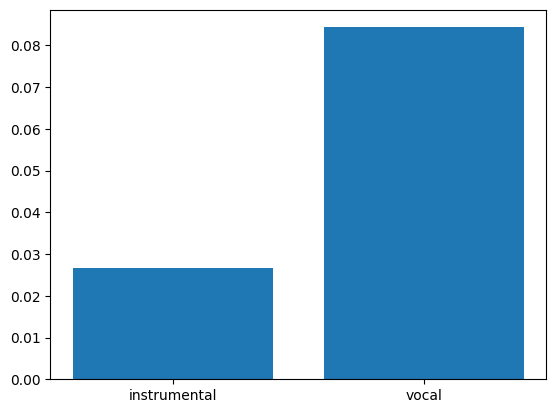

In [24]:
cs = bellier_out["component_stats"]

k = cs["best_component"]

mean_instr = cs["mean_instr"][k]
mean_vocal = cs["mean_vocal"][k]
plt.bar(["instrumental", "vocal"], [mean_instr, mean_vocal])

In [ ]:
Decoding Performance:

In [25]:
top_elec = bellier_out['top_electrodes']['electrode_index'][:7]
random_elec = np.random.choice(all_electrodes, 7, replace=False)

bellier_compare = pipeline.run_bellier_top7_vs_random_avg(
    bellier_out,
    n_random=100,
    seed=0,
)

display(bellier_compare["summary"])

  [decoder] subset=top7       n_elec=    7 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.615 CI=[0.591, 0.630]
    cnn     bacc=0.657 CI=[0.630, 0.675] (n_elec_in=7)


KeyError: 'logreg bacc'

In [11]:
top_elec = bellier_out['top_electrodes']['electrode_index'][:7]
random_elec = np.random.choice(all_electrodes, 7, replace=False)

bellier_compare = pipeline.run_bellier_top7_vs_random_avg(
    bellier_out,
    n_random=100,
    seed=0,
)

display(bellier_compare["summary"])

rand = bellier_compare["random_bacc"]
top = bellier_compare["top_bacc"]

plt.figure(figsize=(6,4))
plt.hist(rand, bins=20)
plt.axvline(top, linewidth=2, label="top 7")
plt.xlabel("balanced accuracy")
plt.ylabel("count")
plt.title("Top 7 vs random 7 (Bellier)")
plt.legend()
plt.show()

KeyError: 'all'

In [21]:
from logic.bellier_decoder import run_vocal_instrumental_decoder

# make sure these exist
top_idx = bellier_out["top_electrodes"]["electrode_index"][:7]

top_res = run_vocal_instrumental_decoder(
    supergrid,
    {"top7": top_idx},
    vocal_mask,
    subsets=["top7"],
    seed=0,
)

print(top_res["summary"].columns.tolist())
display(top_res["summary"])

NameError: name 'vocal_mask' is not defined

  [decoder] subset=true_subset n_elec=    7 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.615 CI=[0.591, 0.630]
    cnn     bacc=0.657 CI=[0.630, 0.675] (n_elec_in=7)
  [decoder] subset=rand_subset n_elec=    7 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.506 CI=[0.494, 0.515]
    cnn     skipped (logreg bacc 0.506 < chance+0.05 = 0.550)
  [decoder] subset=rand_subset n_elec=    7 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.621 CI=[0.590, 0.632]
    cnn     bacc=0.644 CI=[0.619, 0.664] (n_elec_in=7)
  [decoder] subset=rand_subset n_elec=    7 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.466 CI=[0.450, 0.467]
    cnn     skipped (logreg bacc 0.466 < chance+0.05 = 0.550)
  [decoder] subset=rand_subset n_elec=    7 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.502 CI=[0.498, 0.512]
    cnn     skipped (logreg bacc 0.502 < chance+0.05 = 0.550)
  [decoder] subset=rand_subset n_elec=    7 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.518 CI=[0.501, 0.527]
    cnn     skipped (logre

,task,subset_size,n_random_subsets,true_score,null_mean,null_std,null_median,empirical_p_greater
0,bellier_vocal_vs_instrumental,7,5,0.615391,0.522569,0.052105,0.506237,0.333333


  [decoder] subset=all        n_elec= 2395 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.777 CI=[0.731, 0.773]
    cnn     bacc=0.710 CI=[0.675, 0.719] (n_elec_in=256)


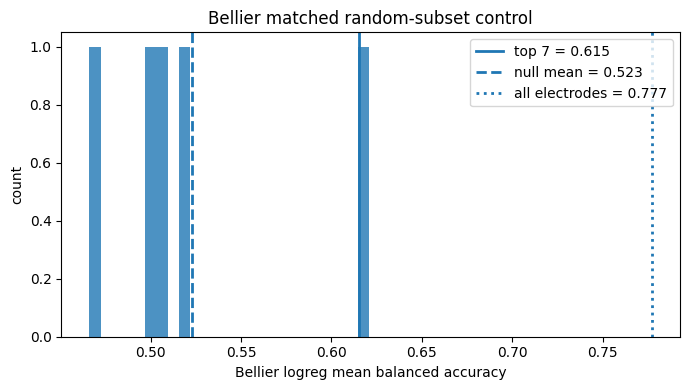

empirical p: 0.3333333333333333


In [34]:
from logic.bellier_data import build_supergrid, load_vocal_segments
from logic.bellier_decoder import run_vocal_instrumental_decoder

# --- load data ---
supergrid = build_supergrid(cache=True, verbose=False)
vocal_mask = load_vocal_segments()

# --- top electrodes ---
top_idx = bellier_out["top_electrodes"]["electrode_index"][:7]

# --- run null distribution ---
bellier_null = pipeline.run_bellier_matched_random_subset_control(
    bellier_out,
    n_subsets=5,
    subset_size=7,
    seed=0,
)

display(bellier_null["summary"])

# --- extract values ---
null_scores = bellier_null["null_scores"]
true_score = bellier_null["true_score"]
null_mean = np.mean(null_scores)

# --- compute "all electrodes" performance ---
all_res = run_vocal_instrumental_decoder(
    supergrid,
    {"all": np.arange(supergrid["hfa"].shape[1])},
    vocal_mask,
    subsets=["all"],
    seed=0,
)

all_bacc = float(
    all_res["summary"]
    .query("model == 'logreg'")["mean_bacc"]
    .iloc[0]
)

# --- plot ---
plt.figure(figsize=(7, 4))
plt.hist(null_scores, bins=25, alpha=0.8)

# top 7
plt.axvline(
    true_score,
    linewidth=2,
    label=f"top 7 = {true_score:.3f}",
)

# null mean
plt.axvline(
    null_mean,
    linestyle="--",
    linewidth=2,
    label=f"null mean = {null_mean:.3f}",
)

# all electrodes
plt.axvline(
    all_bacc,
    linestyle=":",
    linewidth=2,
    label=f"all electrodes = {all_bacc:.3f}",
)

plt.xlabel("Bellier logreg mean balanced accuracy")
plt.ylabel("count")
plt.title("Bellier matched random-subset control")
plt.legend()
plt.tight_layout()
plt.show()

# --- empirical p-value ---
p = (1 + np.sum(null_scores >= true_score)) / (len(null_scores) + 1)
print("empirical p:", p)

In [32]:
import importlib
import logic.pipeline as pipeline
importlib.reload(pipeline)

<module 'logic.pipeline' from '/Users/georgiahutchinson/Desktop/Coursework/Neuro120/neuro120-project-main/logic/pipeline.py'>